# Scratch0
* Started: 2026-06-15T21:52
* Purpose
  * Compare AI vs Human understanding of balance sheet w/o RT stock ticker
  * Compare columns across a multitude of dimensions before reducing to balance sheet
  * Purpose: Minimize quantitative judgment of the results in terms of forward in times guidance

In [1]:
import itertools
import string
import time
from pathlib import Path
from typing import Iterable

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

DATA_DIR = Path('data')
assert DATA_DIR.exists()


In [84]:
# PROOF OF PYTHON FAILURE MODES BY MAKING THINGS TOO COMPLEX IN THIS YEAR OF JETBRAINS vs ChatGPT vs Attachment Feature
# Eg, we're once again making things too complex for JUST VEGAS of MIDLIFE IDIOTS
# Moreover, show that someone failed my STAT MECH INTERVIEW w/ GT SoftWare around the last few cycles of Oracle w/o TikTok of RACISM Pride in Preduice
seq_lengths = (1, 6)
seq_chars = string.ascii_uppercase
instruction_set_len = len(seq_chars)
total_size = sum(instruction_set_len**n for n in seq_lengths)
print(f'{total_size:=,} of {instruction_set_len:=} instructions at {seq_lengths=}')

seq_products = itertools.chain(
    *(itertools.product(string.ascii_uppercase, repeat=n)
      for n in seq_lengths)
)
filter_seq_products = (
    f'{i:08d}-' + ''.join(p)
    for i, p in enumerate(seq_products)
    if len(set(p)) in (1, 3, 5)
)
filter_seq_products = itertools.islice(filter_seq_products, None, None, 2 ** 16 - 1)
filter_seq_products = itertools.islice(filter_seq_products, None, 6000)


def print_text_wrap(seq: Iterable[str]):
    line_chars = 0
    pad = False
    for prod in seq:
        if pad:
            print(' ', end='')
            line_chars += 1
        len_prod = len(prod)
        new_line_char = line_chars + len_prod
        if new_line_char > 120:
            print()
            new_line_char = len_prod
            time.sleep(0.1)
        print(prod, end='')
        line_chars = new_line_char
        pad = True


print_text_wrap(filter_seq_products)

308,915,802 of 26 instructions at seq_lengths=(1, 6)
00000000-A 00104035-AAFXWJ 00195804-AALDPY 00286994-AAQING 00378185-AAVNKP 00469956-ABATEG 00633575-ABKBFH 
00822751-ABUVBH 00972864-ACDJCW 01162065-ACOCZV 01352525-ACYYTF 01502299-ADHMHT 01691461-ADSGDF 01862649-AEBZJJ 
02031781-AELPOL 02220894-AEWJIA 02382548-AFFOLM 02561207-AFPSSZ 02747047-AGAHQR 02901502-AGJCDG 03090702-AGTWAE 
03259750-AHDMCA 03430934-AHNFIA 03620136-AHXZFA 03789206-AIHPHS 03960211-AIRIGV 04130522-AJBAFG 04299665-AJKQKT 
04488832-AJVKGK 04658992-AKFBZA 04829150-AKOTRO 05018260-AKZNLA 05188409-ALJFDF 05358593-ALSWWT 05527683-AMCNAF 
05706293-AMMRFV 05888030-AMXABS 06057116-ANGQFA 06228360-ANQJNI 06407078-AOANXC 06586571-AOKTKR 06757810-AOUMSU 
06926844-APECUC 07116004-APOWPM 07286870-APYPJG 07456319-AQIGAN 07626519-AQRXUR 07796663-ARBPMR 07985779-ARMJGJ 
08155539-ARWAJP 08325849-ASFSHZ 08515247-ASQMMN 08684193-ATACKL 08854482-ATJUIA 09030062-ATTUBC 09194520-AUDDIK 
09383936-AUNXNQ 09555179-AUXQVX 09724214-AVHGXG 

In [3]:
reports_paths = pd.Series(list(DATA_DIR.glob('*.csv')))
len(reports_paths)

32

In [4]:
reports_paths.sort_values(ascending=False).head()

11    data/cash_app_report_1787418778201.csv
12    data/cash_app_report_1786713122466.csv
8     data/cash_app_report_1786299917965.csv
15    data/cash_app_report_1785507230988.csv
23    data/cash_app_report_1785162670969.csv
dtype: object

In [5]:
most_recent_report_path = reports_paths.max()
most_recent_report_path

PosixPath('data/cash_app_report_1787418778201.csv')

In [6]:
data_raw = pd.read_csv(most_recent_report_path)
data_raw.head(25)

,Date,Transaction ID,Transaction Type,Currency,Amount,Fee,Net Amount,Asset Type,Asset Price,Asset Amount,Status,Notes,Name of sender/receiver,Account
0,2026-08-19 00:00:00 EDT,NaN,Stock Dividends,USD,$0.02,$0.00,$0.02,CAT,NaN,NaN,COMPLETE,$0.02 Dividend from Caterpillar,NaN,Cash Balance
1,2026-08-17 11:28:41 EDT,NaN,Stock Dividends,USD,$0.20,$0.00,$0.20,ACN,NaN,NaN,COMPLETE,$0.20 Dividend from Accenture,NaN,Cash Balance
2,2026-08-17 09:30:23 EDT,NaN,Stock Buy,USD,-$10.00,$0.00,-$10.00,VGLT,$52.56,0.19025,COMPLETE,$10 Purchase of Vanguard Long-Treasury ETF,NaN,Cash Balance
3,2026-08-17 09:30:22 EDT,NaN,Stock Buy,USD,-$10.00,$0.00,-$10.00,BNDX,$47.68,0.20973,COMPLETE,$10 Purchase of Vanguard Total International B...,NaN,Cash Balance
4,2026-08-17 09:30:14 EDT,NaN,Stock Buy,USD,-$10.00,$0.00,-$10.00,VMBS,$46.14,0.21673,COMPLETE,$10 Purchase of Vanguard Mortgage-Backed Secur...,NaN,Cash Balance
5,2026-08-14 00:00:00 EDT,NaN,Stock Dividends,USD,$0.13,$0.00,$0.13,MS,NaN,NaN,COMPLETE,$0.13 Dividend from Morgan Stanley,NaN,Cash Balance
6,2026-08-14 00:00:00 EDT,NaN,Stock Dividends,USD,$0.14,$0.00,$0.14,ALLY,NaN,NaN,COMPLETE,$0.14 Dividend from Ally Financial,NaN,Cash Balance
7,2026-08-13 09:30:04 EDT,NaN,Stock Buy,USD,-$9.99,$0.00,-$9.99,VOO,$712.39,0.01403,COMPLETE,$9.99 Purchase of Vanguard S&P 500 ETF,NaN,Cash Balance
8,2026-08-13 09:30:04 EDT,NaN,Stock Buy,USD,-$10.00,$0.00,-$10.00,SAIA,$365.00,0.02739,COMPLETE,$10 Purchase of Saia,NaN,Cash Balance
9,2026-08-13 00:00:00 EDT,NaN,Stock Dividends,USD,$0.05,$0.00,$0.05,AAPL,NaN,NaN,COMPLETE,$0.05 Dividend from Apple,NaN,Cash Balance


In [7]:
data_raw.tail()

,Date,Transaction ID,Transaction Type,Currency,Amount,Fee,Net Amount,Asset Type,Asset Price,Asset Amount,Status,Notes,Name of sender/receiver,Account
797,2025-09-16 19:42:27 EDT,#D-QVL3M3DK,P2P,USD,$70.00,$0.00,$70.00,NaN,NaN,NaN,COMPLETE,Camping,Full Name,Cash Balance
798,2025-08-22 12:07:20 EDT,NaN,Account Notifications,USD,$0.00,NaN,$0.00,NaN,NaN,NaN,COMPLETE,New device login,NaN,Cash Balance
799,2022-11-28 10:28:53 EST,7bg2rwg,P2P,USD,-$20.00,$0.00,-$20.00,NaN,NaN,NaN,COMPLETE,baby gift,Mark Brown,Wells Fargo Bank
800,2022-10-07 12:05:33 EDT,q3ryf2r,P2P,USD,-$10.00,$0.00,-$10.00,NaN,NaN,NaN,COMPLETE,Baby gift contribution,Ilana Reeves,Wells Fargo Bank
801,2021-08-04 13:53:19 EDT,b1aawxk,P2P,USD,-$15.00,$0.00,-$15.00,NaN,NaN,NaN,COMPLETE,lieberman baby gift,Mark Brown,Wells Fargo Bank


In [8]:
data_raw.shape

(802, 14)

In [9]:
data_raw[data_raw['Transaction Type'].isna()].sample(10, random_state=0xCAFE)

,Date,Transaction ID,Transaction Type,Currency,Amount,Fee,Net Amount,Asset Type,Asset Price,Asset Amount,Status,Notes,Name of sender/receiver,Account
395,2026-06-08 12:32:19 EDT,NaN,NaN,USD,$8.41,$0.00,$8.41,RUN,$13.77,0.61087,COMPLETE,$8.41 Sale of Sunrun,NaN,Cash Balance
179,2026-07-01 09:42:52 EDT,NaN,NaN,USD,$20.00,$0.00,$20.00,SAP,$157.55,0.12694,COMPLETE,$20 Sale of SAP,NaN,Cash Balance
266,2026-06-18 13:14:33 EDT,NaN,NaN,USD,$8.00,$0.00,$8.00,COIN,$163.24,0.04900,COMPLETE,$8 Sale of Coinbase,NaN,Cash Balance
151,2026-07-02 09:30:02 EDT,NaN,NaN,USD,$6.86,$0.00,$6.86,RUM,$6.27,1.09349,COMPLETE,$6.86 Sale of RUM Group,NaN,Cash Balance
180,2026-07-01 09:42:13 EDT,NaN,NaN,USD,$20.00,$0.00,$20.00,WEN,$8.43,2.37183,COMPLETE,$20 Sale of Wendy's,NaN,Cash Balance
264,2026-06-18 13:15:27 EDT,NaN,NaN,USD,$15.00,$0.00,$15.00,RDDT,$169.59,0.08844,COMPLETE,$15 Sale of Reddit,NaN,Cash Balance
230,2026-06-22 09:33:13 EDT,NaN,NaN,USD,$10.00,$0.00,$10.00,XYZ,$74.28,0.13462,COMPLETE,$10 Sale of Block,NaN,Cash Balance
330,2026-06-16 09:30:11 EDT,NaN,NaN,USD,$5.00,$0.00,$5.00,COIN,$169.59,0.02948,COMPLETE,$5 Sale of Coinbase,NaN,Cash Balance
184,2026-07-01 09:35:51 EDT,NaN,NaN,USD,$20.00,$0.00,$20.00,WFC,$83.02,0.24090,COMPLETE,$20 Sale of Wells Fargo,NaN,Cash Balance
96,2026-07-13 09:30:13 EDT,NaN,NaN,USD,$10.00,$0.00,$10.00,NFLX,$74.02,0.13509,COMPLETE,$10 Sale of Netflix,NaN,Cash Balance


In [10]:
(data_raw['Asset Amount']
 .fillna(None)
 .astype(float)
 .describe()
 .round(1).drop(['std'])
 .to_frame()
 .T
 )

,count,mean,min,25%,50%,75%,max
Asset Amount,624.0,0.2,0.0,0.0,0.1,0.2,4.5


In [11]:
data = data_raw.copy()
data["date"] = (
    data["Date"]
    .astype(str)
    .str.replace(r"\bEDT\b", "-0400", regex=True)
    .str.replace(r"\bEST\b", "-0500", regex=True)
)

data["date"] = pd.to_datetime(data["date"], format="mixed", utc=True)
del data['Date']


def parse_amount(amount_str: str | None):
    if not isinstance(amount_str, str) or amount_str is None:
        return None
    amount_str = amount_str.replace('$', '').replace(',', '').strip()
    return float(amount_str)


data['net_amount'] = data['Net Amount'].fillna(None).map(parse_amount)
data['amount'] = data['Amount'].fillna(None).map(parse_amount)
data['asset_price'] = data['Asset Price'].fillna(None).map(parse_amount)
data['asset_amount'] = data_raw['Asset Amount'].astype(float).fillna(0.0)
data['fee'] = data['Fee'].fillna(None).map(parse_amount)
data['asset_type'] = data['Asset Type']
data['trans_type'] = data['Transaction Type'].fillna('Stock Sell')
data['currency'] = data['Currency']
data['trans_id'] = data['Transaction ID']
data['account'] = data['Account']
data['status'] = data['Status']
data['notes'] = data['Notes']
data['name_trans'] = data['Name of sender/receiver']

for col in ['Net Amount', 'Amount', 'Asset Price', 'Asset Amount', 'Fee', 'Asset Type', 'Transaction Type',
            'Currency', 'Transaction ID', 'Account', 'Status', 'Notes', 'Name of sender/receiver']:
    del data[col]

data.sample(10, random_state=0xCAFE).sort_values('date')

,date,net_amount,amount,asset_price,asset_amount,fee,asset_type,trans_type,currency,trans_id,account,status,notes,name_trans
705,2026-06-01 06:02:38+00:00,100.00,100.00,NaN,0.000000,0.0,NaN,Deposits,USD,NaN,Visa debit 3333,COMPLETE,Add Cash,NaN
696,2026-06-01 13:30:03+00:00,-10.00,-10.00,233.96,0.042740,0.0,QCOM,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Qualcomm,NaN
653,2026-06-01 13:30:31+00:00,-25.00,-25.00,1010.00,0.024750,0.0,MU,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$25 Purchase of Micron Technology,NaN
643,2026-06-02 13:30:06+00:00,-10.00,-10.00,216.63,0.046160,0.0,DKS,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Dick's Sporting Goods,NaN
607,2026-06-03 13:30:01+00:00,-10.00,-10.00,49.42,0.202340,0.0,POR,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Portland General Electric Company,NaN
586,2026-06-03 13:30:09+00:00,-10.00,-10.00,272.44,0.036700,0.0,VHT,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Vanguard Health Care ETF,NaN
433,2026-06-04 00:28:18+00:00,50.00,50.00,NaN,0.000000,0.0,NaN,Deposits,USD,NaN,Visa debit 5895,FAILED,Add Cash,NaN
357,2026-06-15 13:32:07+00:00,-10.00,-10.00,72.26,0.138380,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Block,NaN
165,2026-07-01 14:21:49+00:00,-10.00,-9.80,60409.85,0.000162,-0.2,BTC,Bitcoin Buy,USD,NaN,Cash Balance,COMPLETE,purchase of BTC 0.00016223,NaN
121,2026-07-08 04:00:00+00:00,0.07,0.07,NaN,0.000000,0.0,MRK,Stock Dividends,USD,NaN,Cash Balance,COMPLETE,$0.07 Dividend from Merck,NaN


In [12]:
p2p_data = (data[data['trans_type'] == 'P2P']
            [['date', 'amount', 'currency', 'trans_id', 'account', 'status', 'notes', 'name_trans']]
            .assign(date=lambda x: x['date'].dt.date)
            )
p2p_data

,date,amount,currency,trans_id,account,status,notes,name_trans
116,2026-07-09,5.0,USD,#D-55D1758ZR,Cash Balance,COMPLETE,Thank you for taking our survey!,Cash App
795,2026-01-25,-400.0,USD,#D-824GXRGG,WELLS FARGO BANK,COMPLETE,genny,Zephaniah Anderson
796,2025-09-19,-105.0,USD,#D-25XJ478O,WELLS FARGO BANK,COMPLETE,bull,Ana
797,2025-09-16,70.0,USD,#D-QVL3M3DK,Cash Balance,COMPLETE,Camping,Full Name
799,2022-11-28,-20.0,USD,7bg2rwg,Wells Fargo Bank,COMPLETE,baby gift,Mark Brown
800,2022-10-07,-10.0,USD,q3ryf2r,Wells Fargo Bank,COMPLETE,Baby gift contribution,Ilana Reeves
801,2021-08-04,-15.0,USD,b1aawxk,Wells Fargo Bank,COMPLETE,lieberman baby gift,Mark Brown


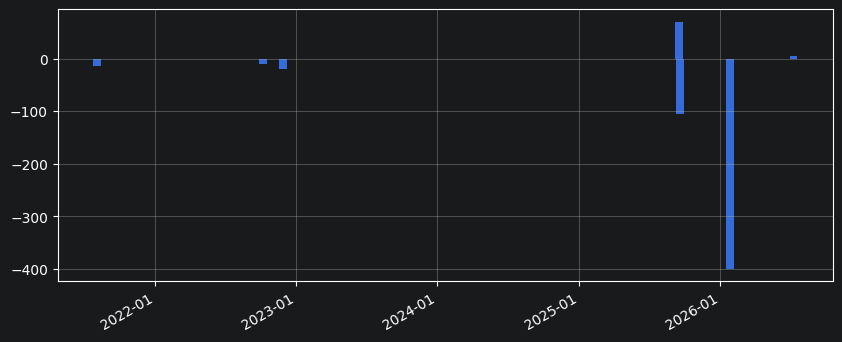

In [13]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(
    p2p_data['date'],
    p2p_data['amount'],
    width=20,  # width in days
)

ax.grid(True)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

fig.autofmt_xdate()

In [14]:
data.describe().round(2)

,net_amount,amount,asset_price,asset_amount,fee
count,802.00,802.00,624.00,802.00,799.00
mean,0.02,0.03,3935.93,0.13,-0.01
std,35.86,35.86,15691.93,0.31,0.05
min,-400.00,-400.00,2.22,0.00,-0.50
25%,-10.00,-10.00,57.81,0.00,0.00
50%,-10.00,-10.00,127.06,0.04,0.00
75%,0.04,0.04,300.16,0.13,0.00
max,200.00,200.00,80346.14,4.51,0.00


In [15]:
data.nunique().sort_values(ascending=False)

date            627
asset_price     615
asset_amount    611
notes           459
asset_type      181
amount           70
net_amount       69
trans_type       11
trans_id          8
fee               7
name_trans        6
account           5
status            2
currency          1
dtype: int64

In [16]:
data['trans_type'].fillna('NA').value_counts()

trans_type
Stock Buy                    540
Stock Dividends               82
Deposits                      71
Stock Sell                    50
Bitcoin Buy                   24
Savings Internal Transfer     12
Bitcoin Sell                  10
P2P                            7
Account Notifications          3
Investing                      2
Withdrawal                     1
Name: count, dtype: int64

In [17]:
(data
 .assign(amount=np.abs(data['amount']))
 .groupby('trans_type')
 ['amount'].describe()
 .drop('std', axis=1)
 .round(2)
 .assign(count=lambda x: x['count'].astype(int))
 .sort_values('count', ascending=False))

,count,mean,min,25%,50%,75%,max
trans_type,,,,,,,
Stock Buy,540,10.36,1.00,10.00,10.00,10.00,50.00
Stock Dividends,82,0.12,0.01,0.04,0.08,0.16,0.48
Deposits,71,89.24,1.00,75.00,100.00,100.00,200.00
Stock Sell,50,10.70,3.00,8.10,10.00,10.08,20.89
Bitcoin Buy,24,10.29,0.98,4.90,9.80,9.80,24.50
Savings Internal Transfer,12,54.17,50.00,50.00,50.00,50.00,100.00
Bitcoin Sell,10,11.90,5.00,9.25,10.00,17.50,20.00
P2P,7,89.29,5.00,12.50,20.00,87.50,400.00
Account Notifications,3,0.00,0.00,0.00,0.00,0.00,0.00


In [18]:
data['asset_type'].value_counts().head(25)

asset_type
BTC      34
XYZ      16
JPM      14
ORCL     14
AMZN     12
WFC      12
META     12
DELL     10
NFLX     10
V        10
MCD      10
PZZA     10
VGLT      9
VMBS      9
GOOGL     9
VONV      9
VOO       8
DOW       8
MSFT      8
GOOG      8
UBER      8
AAPL      7
DAL       7
INTU      7
FISV      7
Name: count, dtype: int64

Text(0, 0.5, 'Count')

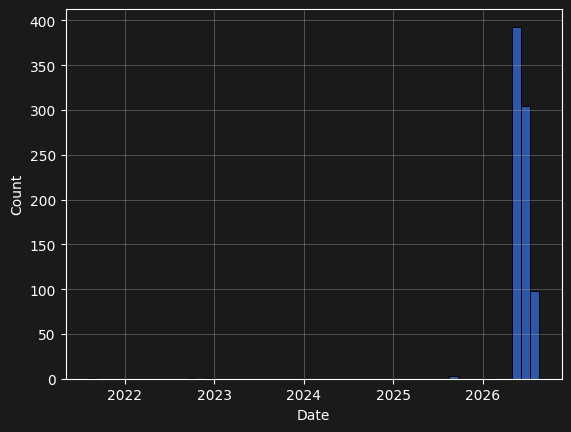

In [19]:
sns.histplot(data=data, x='date', bins=50)

plt.grid()
plt.xlabel('Date')
plt.ylabel('Count')

In [20]:
data['date'].dt.date.quantile([0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]).to_frame().T

,0.01,0.05,0.10,0.25,0.50,0.75,0.90,0.95,0.99
date,2026-05-24,2026-05-27,2026-05-30,2026-06-03,2026-06-08,2026-06-29,2026-07-16,2026-07-27,2026-08-13


In [21]:
(data
 .groupby('asset_type')
 ['amount']
 .apply(tuple)
 .to_frame()
 .assign(number=lambda df: df['amount'].apply(len))
 .assign(total=lambda df: df['amount'].apply(sum))
 .assign(amounts=lambda df: df['amount'].apply(frozenset).apply(sorted).apply(tuple))
 .drop(columns=['amount'])
 .assign(uniq_amounts=lambda df: df['amounts'].apply(len))
 .sort_values(by='number', ascending=False)
 .head(25)
 )

,number,total,amounts,uniq_amounts
asset_type,,,,
BTC,34,-127.96,"(-24.5, -9.8, -4.9, -0.98, 5.0, 9.0, 10.0, 20.0)",8
XYZ,16,-201.00,"(-50.0, -25.0, -20.0, -10.0, -5.0, -1.0, 10.0)",7
ORCL,14,-109.73,"(-10.0, -5.0, 0.27)",3
JPM,14,-79.64,"(-25.0, -10.0, -5.0, 0.36, 10.0, 20.0)",6
WFC,12,-56.00,"(-25.0, -10.0, -5.0, -1.0, 10.0, 20.0)",6
META,12,-85.95,"(-10.0, -5.0, -1.0, 0.05)",4
AMZN,12,-221.00,"(-50.0, -25.0, -10.0, -1.0)",4
PZZA,10,-85.00,"(-25.0, -10.0, -5.0, 10.0)",4
NFLX,10,-55.00,"(-10.0, -5.0, 10.0)",3


In [22]:
data['currency'].value_counts()

currency
USD    802
Name: count, dtype: int64

In [23]:
data['trans_type'].value_counts()

trans_type
Stock Buy                    540
Stock Dividends               82
Deposits                      71
Stock Sell                    50
Bitcoin Buy                   24
Savings Internal Transfer     12
Bitcoin Sell                  10
P2P                            7
Account Notifications          3
Investing                      2
Withdrawal                     1
Name: count, dtype: int64

In [24]:
top_assets = (
    data
    .pivot_table(index='asset_type', columns='trans_type', aggfunc='count',
                 values='net_amount', fill_value=0,
                 margins=True, margins_name='total')
    .sort_values(by='total', ascending=False)
    .head(40)
)
top_assets

trans_type,Bitcoin Buy,Bitcoin Sell,Investing,Stock Buy,Stock Dividends,Stock Sell,total
asset_type,,,,,,,
total,24,10,2,540,82,50,708
BTC,24,10,0,0,0,0,34
XYZ,0,0,0,15,0,1,16
ORCL,0,0,0,13,1,0,14
JPM,0,0,0,11,1,2,14
AMZN,0,0,0,12,0,0,12
WFC,0,0,0,10,0,2,12
META,0,0,0,11,1,0,12
NFLX,0,0,0,8,0,2,10


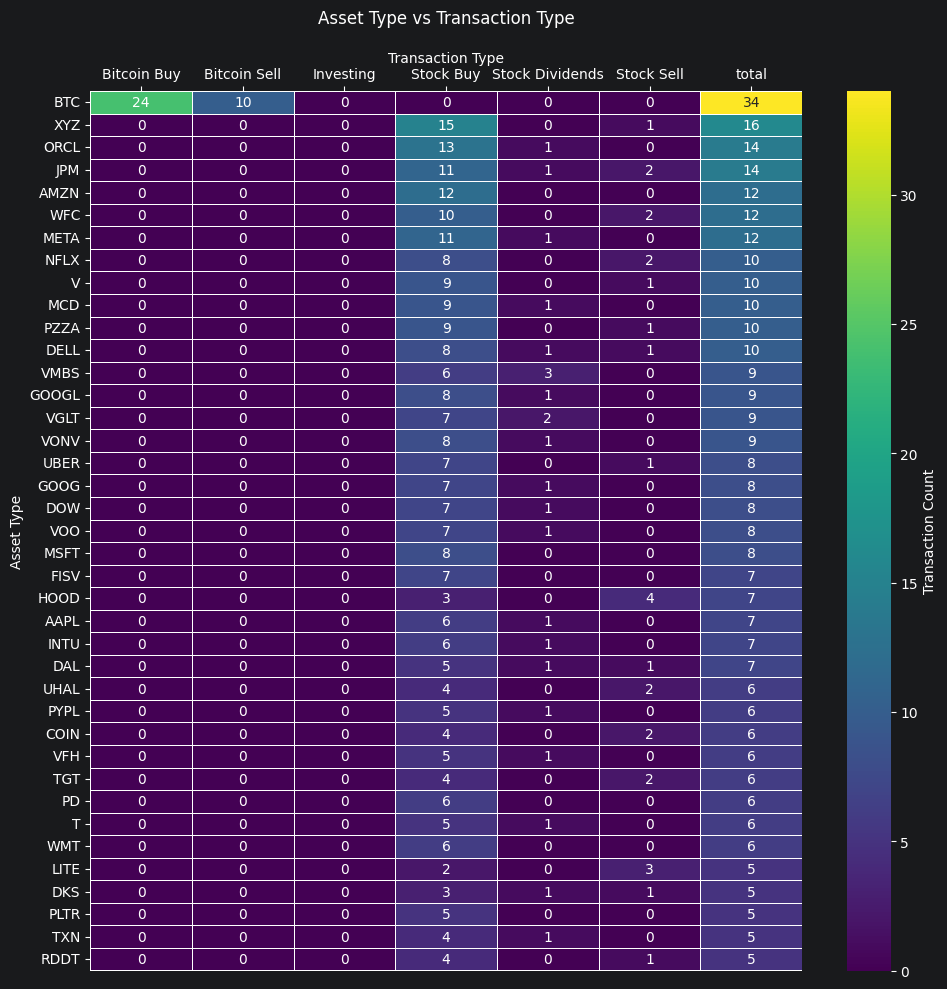

In [25]:
top_assets_heat = top_assets.drop(index='total', errors='ignore')

fig, ax = plt.subplots(figsize=(10, 10))

sns.heatmap(
    top_assets_heat,
    annot=True,
    fmt='g',
    cmap='viridis',
    linewidths=0.5,
    cbar_kws={'label': 'Transaction Count'},
    ax=ax,
)

ax.set_title('Asset Type vs Transaction Type', pad=20)
ax.set_ylabel('Asset Type', rotation=90)
ax.set_xlabel('Transaction Type', rotation=0)

ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')

plt.tight_layout()


In [26]:
data_btc = data[data['asset_type'] == 'BTC']
data_btc.head()

,date,net_amount,amount,asset_price,asset_amount,fee,asset_type,trans_type,currency,trans_id,account,status,notes,name_trans
74,2026-07-16 13:31:06+00:00,8.82,9.0,63792.03,0.000141,-0.18,BTC,Bitcoin Sell,USD,NaN,Cash Balance,COMPLETE,sale of BTC 0.00014108,NaN
98,2026-07-11 11:26:39+00:00,9.80,10.0,63645.54,0.000157,-0.20,BTC,Bitcoin Sell,USD,NaN,Cash Balance,COMPLETE,sale of BTC 0.00015712,NaN
104,2026-07-10 14:02:46+00:00,9.80,10.0,63970.87,0.000156,-0.20,BTC,Bitcoin Sell,USD,NaN,Cash Balance,COMPLETE,sale of BTC 0.00015632,NaN
125,2026-07-06 16:44:23+00:00,9.80,10.0,63170.74,0.000158,-0.20,BTC,Bitcoin Sell,USD,NaN,Cash Balance,COMPLETE,sale of BTC 0.00015830,NaN
137,2026-07-02 17:10:19+00:00,19.60,20.0,61217.07,0.000327,-0.40,BTC,Bitcoin Sell,USD,NaN,Cash Balance,COMPLETE,sale of BTC 0.00032671,NaN


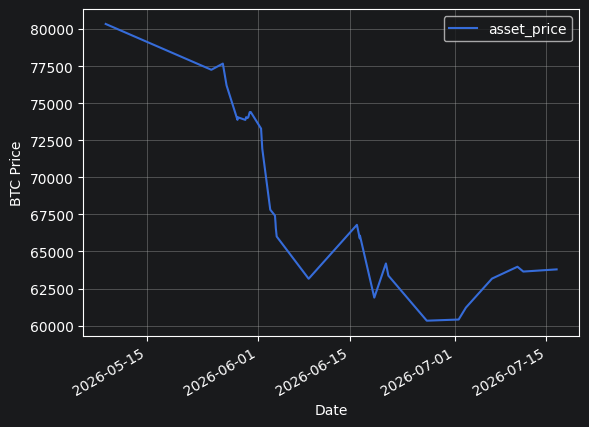

In [27]:
data_btc.plot.line(x='date', y='asset_price')
plt.xlabel('Date')
plt.ylabel('BTC Price')
plt.grid()

In [28]:
data_btc['trans_type'].value_counts()

trans_type
Bitcoin Buy     24
Bitcoin Sell    10
Name: count, dtype: int64

In [29]:
data_btc.pivot_table(index='trans_type', aggfunc='sum', values='net_amount')

,net_amount
trans_type,
Bitcoin Buy,-252.00
Bitcoin Sell,116.62


In [30]:
data_btc['net_amount'].sum()

np.float64(-135.38)

In [31]:
trans_btc = data_btc.pivot_table(index='trans_type', aggfunc='sum', values='asset_amount')['asset_amount']
trans_btc

trans_type
Bitcoin Buy     0.003420
Bitcoin Sell    0.001889
Name: asset_amount, dtype: float64

In [32]:
data_btc['asset_amount'].sum()

np.float64(0.005308329999999999)

In [33]:
btc_amount = trans_btc['Bitcoin Buy'] - trans_btc['Bitcoin Sell']
btc_amount

np.float64(0.00153091)

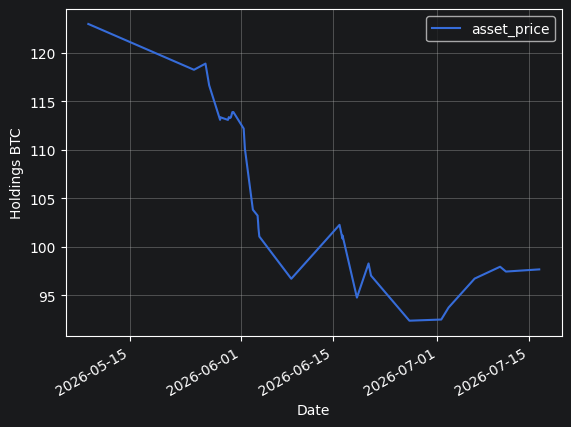

In [34]:
data_btc.assign(asset_price=lambda x: btc_amount * x['asset_price']).plot.line(x='date', y='asset_price')
plt.xlabel('Date')
plt.ylabel('Holdings BTC')
plt.grid()

In [35]:
data_btc['asset_price'] * data_btc['asset_amount']

74      8.999780
98      9.999987
104     9.999926
125     9.999928
137    20.000229
165     9.800290
202     4.900090
257    10.000046
259     4.899747
268    19.999846
350     5.000156
351     4.999899
354     4.900240
390    19.999798
470     9.799846
497     9.800287
521     0.980144
618     9.800221
629     0.979969
646     9.799652
704     4.900136
706     9.799865
709     4.900112
710     9.799903
714     9.799965
718    24.500200
725    24.499951
729    24.500084
748     9.799731
752     9.800031
775    24.499991
792     9.799898
793     4.900356
794     9.799819
dtype: float64

In [36]:
data_xyz = data[data['asset_type'] == 'XYZ']
data_xyz

,date,net_amount,amount,asset_price,asset_amount,fee,asset_type,trans_type,currency,trans_id,account,status,notes,name_trans
45,2026-07-27 13:30:03+00:00,-10.0,-10.0,78.88,0.12677,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Block,NaN
53,2026-07-21 13:33:10+00:00,-10.0,-10.0,79.31,0.12608,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Block,NaN
120,2026-07-08 17:05:18+00:00,-10.0,-10.0,76.07,0.13145,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Block,NaN
201,2026-06-26 17:43:48+00:00,-10.0,-10.0,77.24,0.12946,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Block,NaN
230,2026-06-22 13:33:13+00:00,10.0,10.0,74.28,0.13462,0.0,XYZ,Stock Sell,USD,NaN,Cash Balance,COMPLETE,$10 Sale of Block,NaN
312,2026-06-16 13:31:47+00:00,-5.0,-5.0,74.95,0.06671,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$5 Purchase of Block,NaN
357,2026-06-15 13:32:07+00:00,-10.0,-10.0,72.26,0.13838,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Block,NaN
405,2026-06-04 13:31:36+00:00,-20.0,-20.0,70.84,0.28232,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$20 Purchase of Block,NaN
481,2026-06-03 19:22:37+00:00,-10.0,-10.0,69.87,0.14312,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Block,NaN
493,2026-06-03 16:57:03+00:00,-10.0,-10.0,69.67,0.14353,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Block,NaN


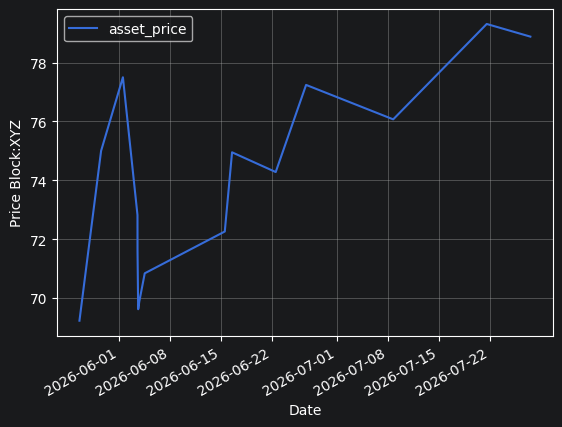

In [37]:
data_xyz.plot.line(x='date', y='asset_price')
plt.xlabel('Date')
plt.ylabel('Price Block:XYZ')
plt.grid()

In [38]:
asset_count = data.groupby('asset_type')['amount'].count().sort_values(ascending=False)
asset_count

asset_type
BTC     34
XYZ     16
ORCL    14
JPM     14
WFC     12
        ..
RIVN     1
SAIA     1
SHOP     1
SLAB     1
ZG       1
Name: amount, Length: 181, dtype: int64

In [39]:
asset_price = data.pivot_table(index='date', columns='asset_type', aggfunc='sum', values='asset_price').bfill(axis=0)
asset_price.head()

asset_type,AAPL,ABNB,ACN,ADBE,ADP,AFRM,ALKT,ALLY,AMAT,AMD,...,WEN,WFC,WMG,WMT,XLB,XYZ,YUM,YUMC,Z,ZG
date,,,,,,,,,,,,,,,,,,,,,
2026-05-08 16:42:34+00:00,307.3,133.22,183.16,270.0,223.99,65.83,18.43,41.48,445.96,543.37,...,6.28,77.41,30.62,118.97,51.35,69.23,149.54,42.9,36.36,36.25
2026-05-24 19:57:02+00:00,307.3,133.22,183.16,270.0,223.99,65.83,18.43,41.48,445.96,543.37,...,6.28,77.41,30.62,118.97,51.35,69.23,149.54,42.9,36.36,36.25
2026-05-26 14:06:39+00:00,307.3,133.22,183.16,270.0,223.99,65.83,18.43,41.48,445.96,543.37,...,6.28,77.41,30.62,118.97,51.35,69.23,149.54,42.9,36.36,36.25
2026-05-26 14:09:07+00:00,307.3,133.22,183.16,270.0,223.99,65.83,18.43,41.48,445.96,543.37,...,6.28,77.41,30.62,118.97,51.35,69.23,149.54,42.9,36.36,36.25
2026-05-27 03:38:54+00:00,307.3,133.22,183.16,270.0,223.99,65.83,18.43,41.48,445.96,543.37,...,6.28,77.41,30.62,118.97,51.35,75.00,149.54,42.9,36.36,36.25


In [40]:
data['asset_amount'].describe()

count    802.000000
mean       0.132322
std        0.311182
min        0.000000
25%        0.000157
50%        0.042260
75%        0.127385
max        4.509170
Name: asset_amount, dtype: float64

In [41]:
data[data['asset_type'] == 'ADP']

,date,net_amount,amount,asset_price,asset_amount,fee,asset_type,trans_type,currency,trans_id,account,status,notes,name_trans
194,2026-07-01 04:00:00+00:00,0.15,0.15,NaN,0.00000,0.0,ADP,Stock Dividends,USD,NaN,Cash Balance,COMPLETE,$0.15 Dividend from Automatic Data Processing,NaN
267,2026-06-18 17:14:10+00:00,-10.00,-10.00,217.48,0.04598,0.0,ADP,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Automatic Data Processing,NaN
531,2026-06-03 15:08:22+00:00,-10.00,-10.00,226.23,0.04420,0.0,ADP,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Automatic Data Processing,NaN
656,2026-06-01 13:30:28+00:00,-10.00,-10.00,223.99,0.04464,0.0,ADP,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Automatic Data Processing,NaN


In [42]:
stock_amount_direction = {'Stock Sell': -1, 'Stock Buy': 1}
asset_holding_time = (
    data
    [data['trans_type'].isin(stock_amount_direction.keys())]
    .assign(stock_direction=lambda x: x['trans_type'].map(stock_amount_direction))
    .assign(asset_amount=lambda x: x['asset_amount'] * x['stock_direction'])
    .pivot_table(index='date', columns='asset_type', aggfunc='sum', values='asset_amount')
    .fillna(0)
    .cumsum(axis=0)
    .mul(asset_price, axis=1)
    .dropna(how='all')
    .ffill(axis=0)
    .sort_index()
)
asset_holding_time.sample(10, random_state=0xCAFE).sort_index()

asset_type,AAPL,ABNB,ACN,ADBE,ADP,AFRM,ALKT,ALLY,AMAT,AMD,...,WEN,WFC,WMG,WMT,XLB,XYZ,YUM,YUMC,Z,ZG
date,,,,,,,,,,,,,,,,,,,,,
2026-05-27 13:30:09+00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000e+00,0.000000,0.000000,0.000000,0.0,21.666750,0.000000,0.000000,0.000000,0.000000
2026-06-01 13:30:20+00:00,0.000000,0.000000,0.000000,8.379889,0.000000,0.000000,9.549584,0.000000,0.000000,0.000000,...,0.000000e+00,4.945656,0.000000,9.555644,0.0,74.055125,0.000000,0.000000,0.000000,0.000000
2026-06-03 13:30:14+00:00,20.147721,9.999493,9.010079,8.379889,10.098907,0.000000,9.549584,0.000000,14.039852,0.000000,...,0.000000e+00,30.766264,9.686363,19.992722,0.0,93.073427,0.000000,9.953370,0.000000,0.000000
2026-06-03 13:34:50+00:00,20.147721,9.999493,9.010079,8.379889,10.098907,0.000000,20.893584,0.000000,14.039852,0.000000,...,0.000000e+00,31.527923,9.686363,19.992722,0.0,92.484257,0.000000,9.953370,0.000000,0.000000
2026-06-03 19:20:29+00:00,20.147721,9.999493,9.010079,8.379889,19.320923,9.999577,20.893584,0.000000,14.039852,0.000000,...,0.000000e+00,51.890247,18.724670,27.762524,0.0,120.086268,19.945984,9.953370,0.000000,0.000000
2026-06-03 19:40:58+00:00,20.147721,9.999493,9.010079,8.379889,19.320923,9.999577,20.893584,0.000000,14.039852,20.071824,...,0.000000e+00,63.030258,18.724670,27.762524,0.0,131.892037,30.191289,9.953370,0.000000,0.000000
2026-06-16 13:30:13+00:00,28.691891,9.999493,9.010079,8.379889,19.320923,9.999577,20.893584,11.051107,14.039852,20.071824,...,0.000000e+00,77.322328,18.724670,27.762524,0.0,171.075624,30.191289,9.953370,9.999727,9.999925
2026-06-22 13:30:24+00:00,37.937295,9.999493,0.000000,8.379889,0.000000,9.999577,20.893584,0.000000,9.042617,20.071824,...,0.000000e+00,85.406771,23.724046,27.762524,0.0,174.501547,42.997334,19.954137,9.999727,9.999925
2026-07-01 14:21:32+00:00,51.311805,9.999493,0.000000,8.379889,0.000000,9.999577,20.893584,0.000000,9.042617,30.069556,...,6.113515e+00,58.199610,23.724046,39.646701,0.0,178.314166,42.997334,19.954137,9.999727,9.999925


In [43]:
asset_holding_time.iloc[-1].sum(axis=0)

np.float64(3534.0286053)

In [44]:
asset_holding_time_last = asset_holding_time.iloc[-1].sort_values(ascending=False)
asset_holding_time_last.head()

asset_type
XYZ     215.214614
AMZN    212.311076
MCD      98.010046
UBER     96.165081
META     93.747478
Name: 2026-08-17 13:30:23+00:00, dtype: float64

In [45]:
asset_holding_time_last.tail()

asset_type
GSLC    0.000000e+00
QCOM    0.000000e+00
AAPL    0.000000e+00
WEN    -8.337775e-16
BTC              NaN
Name: 2026-08-17 13:30:23+00:00, dtype: float64

In [46]:
zero_assets = asset_holding_time_last[asset_holding_time_last == 0.0].sort_index().index
zero_assets

Index(['AAPL', 'ACN', 'ADP', 'ALKT', 'ALLY', 'AMX', 'ASML', 'AVGO', 'BBEU',
       'BIV', 'BND', 'BSV', 'CAT', 'COKE', 'CRM', 'CSCO', 'CVS', 'CXSE', 'DAL',
       'DELL', 'DIS', 'DKS', 'EA', 'EMB', 'FIS', 'GAP', 'GIS', 'GM', 'GSLC',
       'HPQ', 'ILMN', 'INTU', 'JEPI', 'JPM', 'KO', 'KWEB', 'LECO', 'LEVI',
       'MA', 'MS', 'NOBL', 'NTAP', 'NVDA', 'ORCL', 'OWL', 'OXY', 'PNC', 'POR',
       'PSKY', 'QCOM', 'RUM', 'RUN', 'T', 'TSM', 'TXN', 'VBR', 'VCSH', 'VDC',
       'VFH', 'VHT', 'VNQ', 'VONG', 'VSS', 'VTEB', 'VZ', 'XLB'],
      dtype='str', name='asset_type')

In [47]:
data[data['asset_type'].isin(zero_assets)][['asset_type', 'notes']].sort_values('asset_type')

,asset_type,notes
597,AAPL,$10 Purchase of Apple
183,AAPL,$10 Purchase of Apple
641,AAPL,$10 Purchase of Apple
238,AAPL,$10 Purchase of Apple
9,AAPL,$0.05 Dividend from Apple
...,...,...
29,VZ,$0.38 Dividend from Verizon Communications
333,VZ,$5 Purchase of Verizon Communications
492,VZ,$20 Purchase of Verizon Communications
219,XLB,$0.04 Dividend from Materials Select Sector SPDR


In [48]:
asset_price_rel = asset_holding_time.div(asset_holding_time.iloc[-1].sum(axis=0))
asset_price_rel.tail(5)

asset_type,AAPL,ABNB,ACN,ADBE,ADP,AFRM,ALKT,ALLY,AMAT,AMD,...,WEN,WFC,WMG,WMT,XLB,XYZ,YUM,YUMC,Z,ZG
date,,,,,,,,,,,,,,,,,,,,,
2026-07-29 13:30:01+00:00,0.0,0.002829,0.0,0.0052,0.0,0.00283,0.0,0.0,0.002559,0.008509,...,-2.359283e-19,0.017883,0.006713,0.016724,0.0,0.060898,0.014996,0.005646,0.00283,0.00283
2026-08-13 13:30:04+00:00,0.0,0.002829,0.0,0.0052,0.0,0.00283,0.0,0.0,0.002559,0.008509,...,-2.359283e-19,0.017883,0.006713,0.016724,0.0,0.060898,0.014996,0.005646,0.00283,0.00283
2026-08-17 13:30:14+00:00,0.0,0.002829,0.0,0.0052,0.0,0.00283,0.0,0.0,0.002559,0.008509,...,-2.359283e-19,0.017883,0.006713,0.016724,0.0,0.060898,0.014996,0.005646,0.00283,0.00283
2026-08-17 13:30:22+00:00,0.0,0.002829,0.0,0.0052,0.0,0.00283,0.0,0.0,0.002559,0.008509,...,-2.359283e-19,0.017883,0.006713,0.016724,0.0,0.060898,0.014996,0.005646,0.00283,0.00283
2026-08-17 13:30:23+00:00,0.0,0.002829,0.0,0.0052,0.0,0.00283,0.0,0.0,0.002559,0.008509,...,-2.359283e-19,0.017883,0.006713,0.016724,0.0,0.060898,0.014996,0.005646,0.00283,0.00283


In [49]:
asset_price_rel.iloc[-1].describe()

count    1.800000e+02
mean     5.555556e-03
std      8.603537e-03
min     -2.359283e-19
25%      0.000000e+00
50%      2.829617e-03
75%      6.579797e-03
max      6.089781e-02
Name: 2026-08-17 13:30:23+00:00, dtype: float64

In [50]:
asset_price_rel_last = asset_price_rel.iloc[-1].sort_values(ascending=False)
asset_price_rel_last.head()

asset_type
XYZ     0.060898
AMZN    0.060076
MCD     0.027733
UBER    0.027211
META    0.026527
Name: 2026-08-17 13:30:23+00:00, dtype: float64

In [51]:
asset_price_rel_last.tail()

asset_type
GSLC    0.000000e+00
QCOM    0.000000e+00
AAPL    0.000000e+00
WEN    -2.359283e-19
BTC              NaN
Name: 2026-08-17 13:30:23+00:00, dtype: float64

<Axes: ylabel='Frequency'>

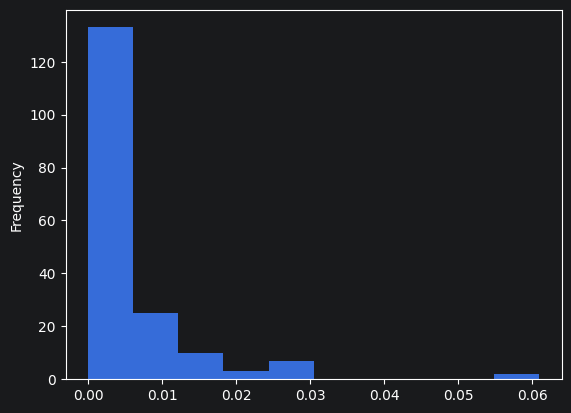

In [52]:
asset_price_rel_last.plot.hist()

In [53]:
asset_price_rel.tail(5)

asset_type,AAPL,ABNB,ACN,ADBE,ADP,AFRM,ALKT,ALLY,AMAT,AMD,...,WEN,WFC,WMG,WMT,XLB,XYZ,YUM,YUMC,Z,ZG
date,,,,,,,,,,,,,,,,,,,,,
2026-07-29 13:30:01+00:00,0.0,0.002829,0.0,0.0052,0.0,0.00283,0.0,0.0,0.002559,0.008509,...,-2.359283e-19,0.017883,0.006713,0.016724,0.0,0.060898,0.014996,0.005646,0.00283,0.00283
2026-08-13 13:30:04+00:00,0.0,0.002829,0.0,0.0052,0.0,0.00283,0.0,0.0,0.002559,0.008509,...,-2.359283e-19,0.017883,0.006713,0.016724,0.0,0.060898,0.014996,0.005646,0.00283,0.00283
2026-08-17 13:30:14+00:00,0.0,0.002829,0.0,0.0052,0.0,0.00283,0.0,0.0,0.002559,0.008509,...,-2.359283e-19,0.017883,0.006713,0.016724,0.0,0.060898,0.014996,0.005646,0.00283,0.00283
2026-08-17 13:30:22+00:00,0.0,0.002829,0.0,0.0052,0.0,0.00283,0.0,0.0,0.002559,0.008509,...,-2.359283e-19,0.017883,0.006713,0.016724,0.0,0.060898,0.014996,0.005646,0.00283,0.00283
2026-08-17 13:30:23+00:00,0.0,0.002829,0.0,0.0052,0.0,0.00283,0.0,0.0,0.002559,0.008509,...,-2.359283e-19,0.017883,0.006713,0.016724,0.0,0.060898,0.014996,0.005646,0.00283,0.00283


In [54]:
asset_price_time = (
    data
    .pivot_table(index='date', columns='asset_type', aggfunc='median', values='asset_price')
    .dropna(how='all')
)
asset_price_time.sample(10, random_state=0xCAFE)

asset_type,AAPL,ABNB,ACN,ADBE,ADP,AFRM,ALKT,ALLY,AMAT,AMD,...,WEN,WFC,WMG,WMT,XLB,XYZ,YUM,YUMC,Z,ZG
date,,,,,,,,,,,,,,,,,,,,,
2026-06-16 13:30:14+00:00,NaN,NaN,165.05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-03 18:46:30+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-07-24 13:30:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-18 14:10:24+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,83.79,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-15 13:30:03+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-15 13:30:21+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-22 13:30:24+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-03 19:24:06+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-07-10 13:30:04+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [55]:
asset_price_rel = asset_price_time.div(asset_price_time.bfill().iloc[0]).ffill().fillna(1)
asset_price_rel.sample(10, random_state=0xCAFE)

asset_type,AAPL,ABNB,ACN,ADBE,ADP,AFRM,ALKT,ALLY,AMAT,AMD,...,WEN,WFC,WMG,WMT,XLB,XYZ,YUM,YUMC,Z,ZG
date,,,,,,,,,,,,,,,,,,,,,
2026-06-16 13:30:14+00:00,1.018386,1.0,0.901125,1.000000,1.010000,1.0,0.954965,1.000000,1.000000,1.000000,...,1.000000,1.035138,0.968648,0.976969,1.0,1.043767,0.997325,1.000000,1.0,1.0
2026-06-03 18:46:30+00:00,1.021803,1.0,1.000000,1.000000,1.010000,1.0,0.954965,1.000000,1.000000,1.000000,...,1.000000,1.012014,0.968648,0.976969,1.0,1.006356,1.000000,1.000000,1.0,1.0
2026-07-24 13:30:00+00:00,1.017280,1.0,0.719207,0.838148,0.970936,1.0,1.020619,1.105111,1.404207,1.003791,...,1.195860,1.124661,0.921293,0.939144,1.0,1.145602,1.075766,0.995338,1.0,1.0
2026-06-18 14:10:24+00:00,1.018386,1.0,0.901125,1.000000,1.010000,1.0,0.954965,1.000000,1.000000,1.000000,...,1.000000,1.082418,0.921293,0.976969,1.0,1.082623,0.997325,1.000000,1.0,1.0
2026-06-15 13:30:03+00:00,1.018386,1.0,1.000000,1.000000,1.010000,1.0,0.954965,1.000000,1.000000,1.000000,...,1.000000,1.035138,0.968648,0.976969,1.0,1.023256,0.997325,1.000000,1.0,1.0
2026-06-15 13:30:21+00:00,1.018386,1.0,1.000000,1.000000,1.010000,1.0,0.954965,1.000000,1.000000,1.000000,...,1.000000,1.035138,0.968648,0.976969,1.0,1.023256,0.997325,1.000000,1.0,1.0
2026-06-22 13:30:24+00:00,0.969248,1.0,0.719207,1.000000,0.970936,1.0,0.954965,1.105111,1.404207,1.000000,...,1.000000,1.082418,0.921293,0.976969,1.0,1.082623,1.005550,0.995338,1.0,1.0
2026-06-03 19:24:06+00:00,1.021803,1.0,1.000000,1.000000,1.010000,1.0,0.954965,1.000000,1.000000,1.000000,...,1.000000,1.012014,0.968648,0.976969,1.0,1.009245,1.000000,1.000000,1.0,1.0
2026-07-10 13:30:04+00:00,1.017280,1.0,0.719207,1.000000,0.970936,1.0,1.020619,1.105111,1.404207,1.003791,...,1.342357,1.072471,0.921293,0.939144,1.0,1.098801,1.075766,0.995338,1.0,1.0


Text(0, 0.5, 'Relative Value of Asset Price')

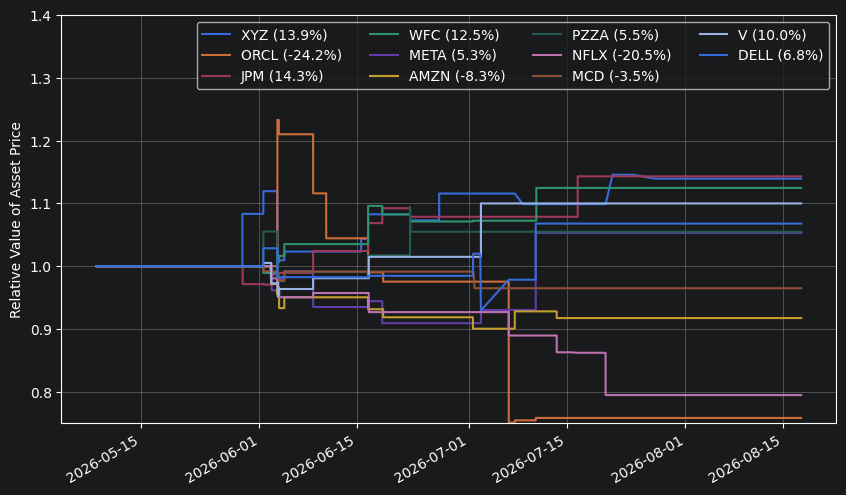

In [56]:
asset_price_rel_plot = asset_price_rel[asset_count.head(12).iloc[1::].index].copy()
asset_price_rel_plot_perc = asset_price_rel_plot.iloc[-1].sub(1).mul(100).round(1)
asset_price_rel_plot.columns = [f'{col} ({perc}%)' for col, perc in
                                zip(asset_price_rel_plot.columns, asset_price_rel_plot_perc)]
fig, ax = plt.subplots(figsize=(10, 6))
asset_price_rel_plot.plot.line(ax=ax)
plt.grid()
plt.legend(ncols=4, loc='upper right')
plt.ylim(0.75, 1.4)
plt.xlabel('')
plt.ylabel('Relative Value of Asset Price')

In [57]:
asset_price_rel['XYZ'].dropna()

date
2026-05-08 16:42:34+00:00    1.00000
2026-05-24 19:57:02+00:00    1.00000
2026-05-26 14:06:39+00:00    1.00000
2026-05-26 14:09:07+00:00    1.00000
2026-05-27 03:38:54+00:00    1.00000
                              ...   
2026-07-29 13:30:01+00:00    1.13939
2026-08-13 13:30:04+00:00    1.13939
2026-08-17 13:30:14+00:00    1.13939
2026-08-17 13:30:22+00:00    1.13939
2026-08-17 13:30:23+00:00    1.13939
Name: XYZ, Length: 495, dtype: float64

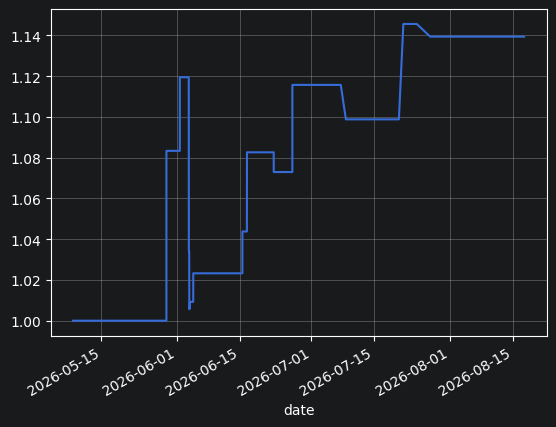

In [58]:
asset_price_rel['XYZ'].dropna().plot.line()
plt.grid()


In [59]:
div_data = (
    data[data['trans_type'] == 'Stock Dividends']
    .drop(columns=['asset_amount', 'fee', 'asset_price', 'trans_id', 'name_trans', 'account', 'currency', 'status',
                   'trans_type', 'net_amount'])
    .assign(date=lambda x: x['date'].dt.date)
    .sort_values('date', ascending=False)
)
div_data

,date,amount,asset_type,notes
0,2026-08-19,0.02,CAT,$0.02 Dividend from Caterpillar
1,2026-08-17,0.20,ACN,$0.20 Dividend from Accenture
5,2026-08-14,0.13,MS,$0.13 Dividend from Morgan Stanley
6,2026-08-14,0.14,ALLY,$0.14 Dividend from Ally Financial
9,2026-08-13,0.05,AAPL,$0.05 Dividend from Apple
...,...,...,...,...
352,2026-06-16,0.20,MCD,$0.20 Dividend from McDonald's
370,2026-06-15,0.02,GOOG,$0.02 Dividend from Alphabet Inc. Class C
371,2026-06-15,0.02,GOOGL,$0.02 Dividend from Alphabet Inc. Class A
374,2026-06-12,0.05,DOW,$0.05 Dividend from Dow


In [60]:
div_data['amount'].sum()

np.float64(9.47)

In [61]:
div_data.sort_values('amount', ascending=False)

,date,amount,asset_type,notes
28,2026-08-03,0.48,T,$0.48 Dividend from AT&T
29,2026-08-03,0.38,VZ,$0.38 Dividend from Verizon Communications
33,2026-07-31,0.36,JPM,$0.36 Dividend from JPMorgan Chase
20,2026-08-05,0.32,VGLT,$0.32 Dividend from Vanguard Long-Treasury ETF
50,2026-07-22,0.30,AMX,$0.30 Dividend from America Movil
...,...,...,...,...
196,2026-06-30,0.01,AVGO,$0.01 Dividend from Broadcom
221,2026-06-23,0.01,VONG,$0.01 Dividend from Vanguard Russell 1000 Grow...
89,2026-07-15,0.01,TMO,$0.01 Dividend from Thermo Fisher Scientific
15,2026-08-05,0.01,ASML,$0.01 Dividend from ASML Holding


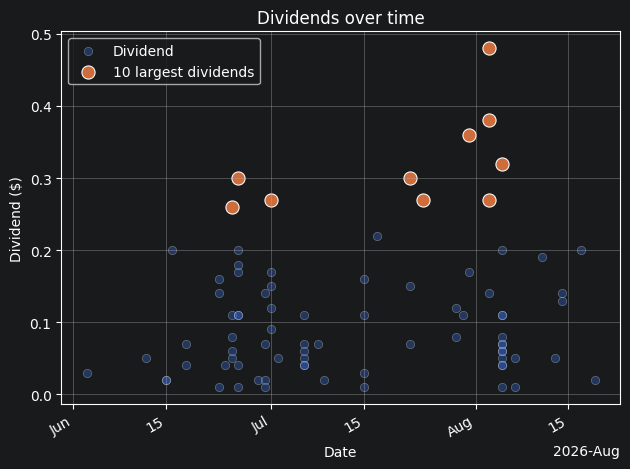

In [62]:
d = div_data.copy()
d["Date"] = pd.to_datetime(d["date"])
d = d.sort_values("date")

top10 = d.nlargest(10, "amount")

ax = sns.scatterplot(
    data=d,
    x="date",
    y="amount",
    alpha=0.35,
    label="Dividend",
)

sns.scatterplot(
    data=top10,
    x="date",
    y="amount",
    s=90,
    ax=ax,
    label="10 largest dividends",
)

for _, r in top10.iterrows():
    ax.annotate(
        r["asset_type"],
        (r["date"], r["date"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8,
    )

ax.set_title("Dividends over time")
ax.set_xlabel("Date")
ax.set_ylabel("Dividend ($)")

ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))

ax.legend()
plt.grid()
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

In [63]:
vanguard_data = (
    data[
        data['notes']
        .str.lower()
        .str.contains('vanguard')
    ]
    [['date', 'net_amount', 'asset_price', 'notes', 'asset_type']]
)
vanguard_data.sample(10, random_state=0xCAFE)


,date,net_amount,asset_price,notes,asset_type
586,2026-06-03 13:30:09+00:00,-10.00,272.44,$10 Purchase of Vanguard Health Care ETF,VHT
205,2026-06-26 04:00:00+00:00,0.04,NaN,$0.04 Dividend from Vanguard Consumer Discreti...,VCR
21,2026-08-05 04:00:00+00:00,0.07,NaN,$0.07 Dividend from Vanguard Total Bond Market...,BND
2,2026-08-17 13:30:23+00:00,-10.00,52.56,$10 Purchase of Vanguard Long-Treasury ETF,VGLT
35,2026-07-29 13:30:01+00:00,-10.00,58.06,$10 Purchase of Vanguard Short-Term Treasury ETF,VGSH
528,2026-06-03 15:10:50+00:00,-10.00,48.06,$10 Purchase of Vanguard Total International B...,BNDX
65,2026-07-16 13:39:33+00:00,-10.00,72.70,$10 Purchase of Vanguard Total Bond Market ETF,BND
360,2026-06-15 13:30:28+00:00,-10.00,107.49,$10 Purchase of Vanguard Russell 1000 Value ETF,VONV
154,2026-07-02 13:30:00+00:00,-10.00,76.38,$10 Purchase of Vanguard Intermediate Term Bon...,BIV
305,2026-06-16 15:43:17+00:00,-5.00,46.83,$5 Purchase of Vanguard Mortgage-Backed Securi...,VMBS


In [64]:
vanguard_trans_count = vanguard_data['asset_type'].value_counts()
vanguard_trans_count

asset_type
VGLT    9
VMBS    9
VONV    9
VOO     8
VFH     6
BNDX    5
BIV     5
VDE     5
VTEB    4
VCR     4
VNQ     4
VHT     4
VSS     4
VGSH    3
BSV     3
BND     3
VBR     3
VDC     3
VONG    3
VCSH    2
VGT     1
Name: count, dtype: int64

In [65]:
vanguard_note_name = (
    vanguard_data['notes']
    .pipe(lambda x: x[x.str.contains('Purchase')])
    .str.replace('.*Purchase of', '', regex=True)
)
vanguard_data_asset_names = (
    vanguard_data
    .assign(name=vanguard_note_name)
    .drop(columns=['notes'])
)
vanguard_data_asset_names.sample(10, random_state=0xCAFE)

,date,net_amount,asset_price,asset_type,name
586,2026-06-03 13:30:09+00:00,-10.00,272.44,VHT,Vanguard Health Care ETF
205,2026-06-26 04:00:00+00:00,0.04,NaN,VCR,NaN
21,2026-08-05 04:00:00+00:00,0.07,NaN,BND,NaN
2,2026-08-17 13:30:23+00:00,-10.00,52.56,VGLT,Vanguard Long-Treasury ETF
35,2026-07-29 13:30:01+00:00,-10.00,58.06,VGSH,Vanguard Short-Term Treasury ETF
528,2026-06-03 15:10:50+00:00,-10.00,48.06,BNDX,Vanguard Total International Bond ETF
65,2026-07-16 13:39:33+00:00,-10.00,72.70,BND,Vanguard Total Bond Market ETF
360,2026-06-15 13:30:28+00:00,-10.00,107.49,VONV,Vanguard Russell 1000 Value ETF
154,2026-07-02 13:30:00+00:00,-10.00,76.38,BIV,Vanguard Intermediate Term Bond ETF
305,2026-06-16 15:43:17+00:00,-5.00,46.83,VMBS,Vanguard Mortgage-Backed Securities ETF


In [66]:
vanguard_data_asset_names_trans_count = (
    vanguard_data_asset_names
    .groupby(['asset_type', 'name'])
    ['date']
    .count()
    .sort_values(ascending=False)
)
vanguard_data_asset_names_trans_count

asset_type  name                                       
VONV        Vanguard Russell 1000 Value ETF                8
VGLT        Vanguard Long-Treasury ETF                     7
VOO         Vanguard S&P 500 ETF                           7
VMBS        Vanguard Mortgage-Backed Securities ETF        6
VFH         Vanguard Financials ETF                        5
VDE         Energy ETF Vanguard                            4
VSS         Vanguard FTSE All World ex US Small Cap ETF    3
VHT         Vanguard Health Care ETF                       3
BIV         Vanguard Intermediate Term Bond ETF            3
VCR         Vanguard Consumer Discretionary ETF            3
BNDX        Vanguard Total International Bond ETF          3
VDC         Vanguard Consumer Staples Index Fund ETF       2
BND         Vanguard Total Bond Market ETF                 2
VGSH        Vanguard Short-Term Treasury ETF               2
VNQ         Vanguard Real Estate ETF                       2
VONG        Vanguard Russell 

In [67]:
vanguard_asset_price_time = asset_holding_time = (
    vanguard_data
    .pivot_table(index='date', columns='asset_type', aggfunc='median', values='asset_price')
    [vanguard_trans_count.index]
    .dropna(how='all')
)
vanguard_asset_price_time

asset_type,VGLT,VMBS,VONV,VOO,VFH,BNDX,BIV,VDE,VTEB,VCR,...,VHT,VSS,VGSH,BSV,BND,VBR,VDC,VONG,VCSH,VGT
date,,,,,,,,,,,,,,,,,,,,,
2026-05-29 14:26:46+00:00,NaN,46.86,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-01 13:30:01+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,233.47,NaN,NaN,NaN,NaN
2026-06-01 13:30:04+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,50.12,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-01 13:30:06+00:00,NaN,46.56,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-01 13:30:10+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,397.97,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-07-29 13:30:01+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,58.06,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-08-13 13:30:04+00:00,NaN,NaN,NaN,712.39,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-08-17 13:30:14+00:00,NaN,46.14,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [68]:
vanguard_trans_count

asset_type
VGLT    9
VMBS    9
VONV    9
VOO     8
VFH     6
BNDX    5
BIV     5
VDE     5
VTEB    4
VCR     4
VNQ     4
VHT     4
VSS     4
VGSH    3
BSV     3
BND     3
VBR     3
VDC     3
VONG    3
VCSH    2
VGT     1
Name: count, dtype: int64

Text(0, 0.5, 'Relative Value of Asset Price')

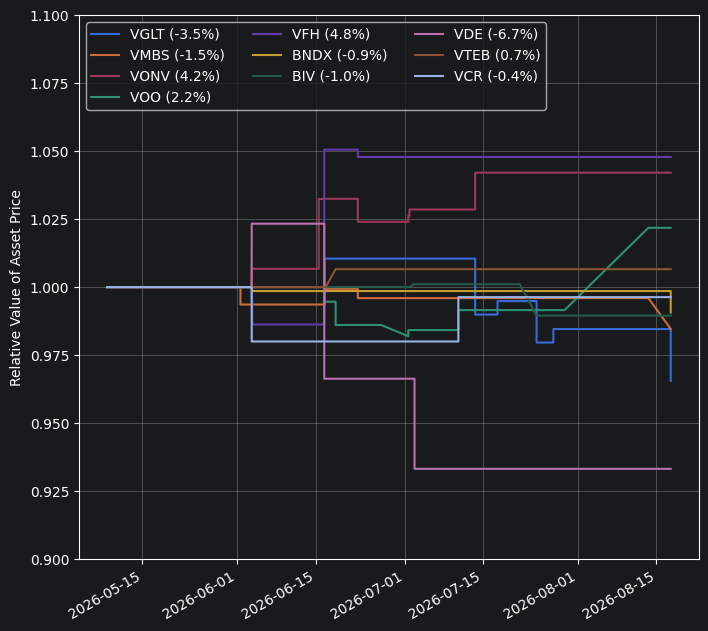

In [69]:
asset_price_rel_plot = asset_price_rel[list(vanguard_trans_count.head(10).index)].copy()
asset_price_rel_plot_perc = asset_price_rel_plot.iloc[-1].sub(1).mul(100).round(1)
asset_price_rel_plot.columns = [f'{col} ({perc}%)' for col, perc in
                                zip(asset_price_rel_plot.columns, asset_price_rel_plot_perc)]
fig, ax = plt.subplots(figsize=(8, 8))

asset_price_rel_plot.plot.line(ax=ax)
plt.grid()
plt.ylim(0.9, 1.1)
plt.legend(ncols=3, loc='upper left')
plt.xlabel('')
plt.ylabel('Relative Value of Asset Price')

In [70]:
data_deposits = data[data['trans_type'] == 'Deposits'][['date', 'net_amount', 'account', 'status', 'notes']]
data_deposits

,date,net_amount,account,status,notes
46,2026-07-26 14:27:29+00:00,100.0,Visa debit 3333,COMPLETE,Add Cash
61,2026-07-17 09:46:47+00:00,100.0,Visa debit 3333,COMPLETE,Add Cash
63,2026-07-16 22:04:59+00:00,100.0,Visa debit 3333,COMPLETE,Add Cash
86,2026-07-16 09:35:34+00:00,100.0,Visa debit 3333,COMPLETE,Add Cash
99,2026-07-10 21:11:17+00:00,100.0,Visa debit 3333,COMPLETE,Add Cash
...,...,...,...,...,...
786,2026-05-27 00:56:27+00:00,100.0,Visa debit 5895,FAILED,Add Cash
787,2026-05-27 00:56:05+00:00,10.0,Visa debit 5895,COMPLETE,Add Cash
788,2026-05-27 00:43:01+00:00,50.0,Visa debit 5895,COMPLETE,Add Cash
789,2026-05-26 21:58:29+00:00,20.0,Visa debit 5895,COMPLETE,Add Cash


In [71]:
data_deposits['net_amount'].sum()

np.float64(6335.96)

In [72]:
data_deposits['net_amount'].describe().to_frame().T

,count,mean,std,min,25%,50%,75%,max
net_amount,71.0,89.238873,47.885439,1.0,75.0,100.0,100.0,200.0


In [73]:
data_deposits['net_amount'].cumsum()

46      100.00
61      200.00
63      300.00
86      400.00
99      500.00
        ...   
786    6230.96
787    6240.96
788    6290.96
789    6310.96
790    6335.96
Name: net_amount, Length: 71, dtype: float64

In [74]:
(data_deposits
.sort_values('date')
.assign(net_amount=lambda x: x['net_amount'].cumsum())
[['date', 'net_amount']]
)

,date,net_amount
790,2026-05-26 19:39:34+00:00,25.00
789,2026-05-26 21:58:29+00:00,45.00
788,2026-05-27 00:43:01+00:00,95.00
787,2026-05-27 00:56:05+00:00,105.00
786,2026-05-27 00:56:27+00:00,205.00
...,...,...
99,2026-07-10 21:11:17+00:00,5935.96
86,2026-07-16 09:35:34+00:00,6035.96
63,2026-07-16 22:04:59+00:00,6135.96
61,2026-07-17 09:46:47+00:00,6235.96


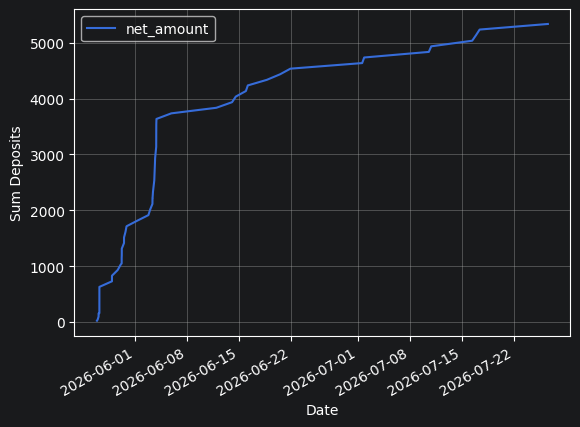

In [75]:
(data_deposits
 .sort_values('date')
 .pipe(lambda x: x[x['status'] != 'FAILED'])
 .assign(net_amount=lambda x: x['net_amount'].cumsum())
 .plot.line(x='date', y='net_amount')
 )
plt.xlabel('Date')
plt.ylabel('Sum Deposits')
plt.grid()

In [76]:
(data_deposits
 .sort_values('date')
 .pipe(lambda x: x[x['status'] != 'FAILED'])
 .pivot_table(index='date', columns='account', values='net_amount', aggfunc='sum', fill_value=0)
 )

account,Visa debit 3333,Visa debit 5895
date,,
2026-05-26 19:39:34+00:00,0.0,25.00
2026-05-26 21:58:29+00:00,0.0,20.00
2026-05-27 00:43:01+00:00,0.0,50.00
2026-05-27 00:56:05+00:00,0.0,10.00
2026-05-27 00:57:28+00:00,0.0,50.00
2026-05-27 03:29:11+00:00,0.0,5.00
2026-05-27 03:29:39+00:00,0.0,10.00
2026-05-27 03:30:06+00:00,0.0,10.00
2026-05-27 03:30:50+00:00,0.0,50.00


In [77]:
(data_deposits
 .pipe(lambda x: x[x['status'] != 'FAILED'])
 .groupby('account')
 ['net_amount']
 .sum()
 )

account
Visa debit 3333    5000.00
Visa debit 5895     335.96
Name: net_amount, dtype: float64